##Development of a Crop Disease Detection System Using Computer Vision Techniques.

## Install and import essential libraries.

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow==2.19.0

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
print("All libraries imported successfully!")

All libraries imported successfully!


## Enable GPU

In [2]:
import tensorflow as tf
print(tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

2026-04-04 13:36:03.040080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775309763.258707      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775309763.326273      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775309763.858298      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775309763.858336      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775309763.858339      55 computation_placer.cc:177] computation placer alr

2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Install Dataset

In [3]:
import os

print(os.listdir("/kaggle/input/datasets/divyanshikhare86/datapvgn/DATA"))

['Corn___Northern_Leaf_Blight', 'Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Background_without_leaves', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn___healthy', 'Strawberry___Leaf_scorch', 'Groundnut___Rust', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Groundnut___healthy', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Groundnut___Alternaria_leaf_spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Groundnut___Rosette', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Corn___Common_rust', 'Apple___healthy', 'Grape___Black_rot', 'Groundnut___Leaf_spot', 'Potato___Early_

In [4]:
dataset_path = "/kaggle/input/datasets/divyanshikhare86/datapvgn/DATA"

Splitting of Data

In [5]:
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=16,
    shuffle=True,
    seed=123
)

Found 57168 files belonging to 44 classes.


I0000 00:00:1775310303.050678      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775310303.056523      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [7]:
class_names = dataset.class_names
print("Number of classes:", len(class_names))

Number of classes: 44


In [8]:
total_size = len(dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size + val_size)

## Confirmation of Splitting of data.

In [9]:
print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))
print("Test batches:", len(test_ds))

Train batches: 2501
Val batches: 535
Test batches: 537


## Data Preprocessing (DO NOT RUN THIS TWICE, MULTIPLE BATCHING WILL DISRUPT CODE!!)

if it shows error, go to runtime -> restart session, and run all execuatble only code again (just install dataset, move, split and preprocess, only one time per block, no need to import or install libraries again)

## Data Augmentation

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

# train_ds = train_ds.prefetch(AUTOTUNE)
# val_ds   = val_ds.prefetch(AUTOTUNE)
# test_ds  = test_ds.prefetch(AUTOTUNE)

In [12]:
for images, labels in train_ds.take(1):
    print(images.shape)
    break

(16, 224, 224, 3)


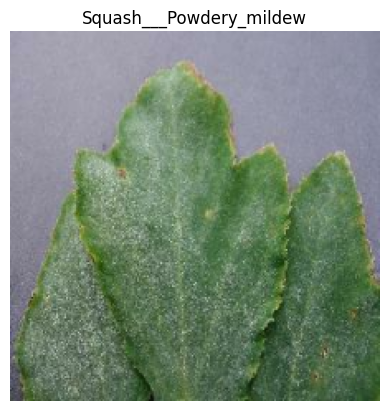

In [14]:
for images, labels in train_ds.take(1):
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(class_names[labels[0].numpy()])
    plt.axis("off")
    plt.show()

## CNN Model Design

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [16]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
base_model.trainable = False

In [18]:
model = models.Sequential([
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,  
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

In [19]:
for layer in model.layers:
    print(layer.name, layer.trainable)

rescaling True
sequential True
mobilenetv2_1.00_224 False
global_average_pooling2d True
dense True
dropout True
dense_1 True


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.build((None, 224, 224, 3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 44)             │        11,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,597,228 (9.91 MB)

 Trainable params: 339,244 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Model Training
  🔹 If accuracy is low <br>
    •	Increase epochs
    •	Add more data
    •	Improve augmentation <br>
  🔹 If overfitting <br>
    •	Increase Dropout
    •	Add more data
    •	Reduce model size <br>
  🔹 If training slow <br>
    •	Use GPU
    •	Reduce image size (optional)


In [23]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10


I0000 00:00:1775312145.001816     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


2501/2501 ━━━━━━━━━━━━━━━━━━━━ 208s 80ms/step - accuracy: 0.5100 - loss: 1.9547 - val_accuracy: 0.8748 - val_loss: 0.4599
Epoch 2/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 148s 59ms/step - accuracy: 0.8281 - loss: 0.5841 - val_accuracy: 0.9033 - val_loss: 0.3243
Epoch 3/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 148s 59ms/step - accuracy: 0.8676 - loss: 0.4316 - val_accuracy: 0.9187 - val_loss: 0.2572
Epoch 4/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 148s 59ms/step - accuracy: 0.8915 - loss: 0.3496 - val_accuracy: 0.9308 - val_loss: 0.2231
Epoch 5/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 148s 59ms/step - accuracy: 0.9046 - loss: 0.3071 - val_accuracy: 0.9315 - val_loss: 0.2086
Epoch 6/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 148s 59ms/step - accuracy: 0.9097 - loss: 0.2777 - val_accuracy: 0.9341 - val_loss: 0.2000
Epoch 7/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 149s 60ms/step - accuracy: 0.9184 - loss: 0.2529 - val_accuracy: 0.9379 - val_loss: 0.1869
Epoch 8/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 154s 62ms/step - accuracy: 0.9220 - lo

In [24]:
base_model.trainable = True

for layer in base_model.layers[:-30]:   # keep most frozen
    layer.trainable = False

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 199s 76ms/step - accuracy: 0.7564 - loss: 0.9845 - val_accuracy: 0.9416 - val_loss: 0.1770
Epoch 2/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 179s 71ms/step - accuracy: 0.9089 - loss: 0.2873 - val_accuracy: 0.9492 - val_loss: 0.1500
Epoch 3/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 176s 70ms/step - accuracy: 0.9205 - loss: 0.2396 - val_accuracy: 0.9565 - val_loss: 0.1284
Epoch 4/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 175s 70ms/step - accuracy: 0.9332 - loss: 0.2009 - val_accuracy: 0.9605 - val_loss: 0.1137
Epoch 5/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 176s 70ms/step - accuracy: 0.9404 - loss: 0.1762 - val_accuracy: 0.9641 - val_loss: 0.1044
Epoch 6/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 177s 71ms/step - accuracy: 0.9455 - loss: 0.1564 - val_accuracy: 0.9676 - val_loss: 0.0973
Epoch 7/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 176s 70ms/step - accuracy: 0.9523 - loss: 0.1412 - val_accuracy: 0.9679 - val_loss: 0.0973
Epoch 8/10
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 178s 71ms/step - accuracy: 

In [28]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

537/537 ━━━━━━━━━━━━━━━━━━━━ 95s 43ms/step - accuracy: 0.9680 - loss: 0.0981
Test Accuracy: 0.9656657576560974


Expectation:

Before TL → ~78%
After TL → 92.5%
After fine-tuning → ~85–92%

In [29]:
model.save("plant_disease_model.h5")

In [30]:
model.save("plant_disease_model.keras")

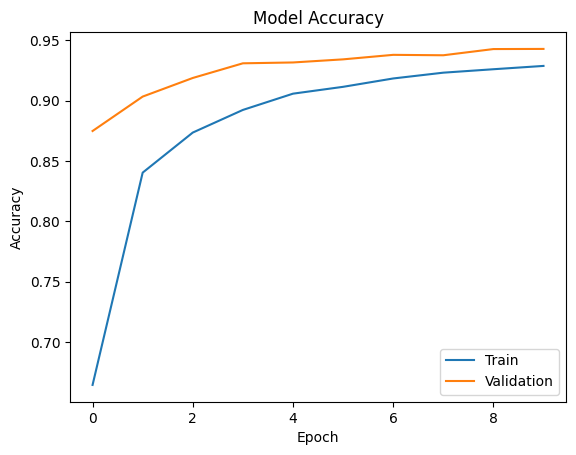

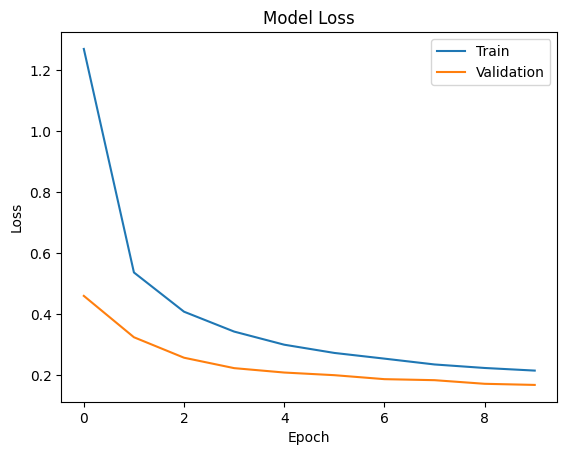

In [31]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()